# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup — rebuild the exact March feature frame 

In [33]:
%pip install -q duckdb scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import os
import getpass
import duckdb
import numpy as np
import pandas as pd

HF_TOKEN = os.environ.get("HF_TOKEN") or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

BASE = "hf://datasets/FlyRank/internship-warehouse"
SNAPSHOT = "2026-03-31"
MONTH = "2026-03"
PREV_MONTH = "2026-02"

print("Connected to Hugging Face warehouse")
print(f"Snapshot date    : {SNAPSHOT}")
print(f"Feature month    : {MONTH}")
print(f"Comparison month : {PREV_MONTH}")

Connected to Hugging Face warehouse
Snapshot date    : 2026-03-31
Feature month    : 2026-03
Comparison month : 2026-02


### 0.1 Rebuild the March / February aggregates and content metadata

In [35]:
# March aggregate -- this month's observable signals, per content item.
con.execute(f"""
    CREATE OR REPLACE TABLE march_agg AS
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions)  AS gsc_impressions_mar,
        SUM(gsc_clicks)       AS gsc_clicks_mar,
        AVG(gsc_avg_position) AS avg_position_mar,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_pageviews ELSE NULL END)        AS ga4_pageviews_mar,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_engaged_sessions ELSE NULL END) AS ga4_engaged_sessions_mar
    FROM read_parquet('{BASE}/fact_content_daily_performance/month={MONTH}/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
""")

# February aggregate -- comparison window, used ONLY to build the proxy label (never a feature).
con.execute(f"""
    CREATE OR REPLACE TABLE feb_agg AS
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS gsc_impressions_feb
    FROM read_parquet('{BASE}/fact_content_daily_performance/month={PREV_MONTH}/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
""")

# Content metadata -- static fields, one row per content item.
con.execute(f"""
    CREATE OR REPLACE TABLE content_meta AS
    SELECT content_hash_id, client_hash_id, content_type, word_count, backlinks,
           content_created_date, content_updated_date,
           last_optimized_date, optimization_eligible_date
    FROM read_parquet('{BASE}/dim_content.parquet')
    WHERE is_published IS TRUE AND is_deleted IS FALSE
""")

print('march_agg, feb_agg, content_meta built.')
con.sql('SELECT COUNT(*) AS march_rows FROM march_agg').show()
con.sql('SELECT COUNT(*) AS content_rows FROM content_meta').show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

march_agg, feb_agg, content_meta built.
┌────────────┐
│ march_rows │
│   int64    │
├────────────┤
│     176738 │
└────────────┘

┌──────────────┐
│ content_rows │
│    int64     │
├──────────────┤
│       411540 │
└──────────────┘



In [36]:
# Join into one content-item-per-row frame with the proxy label -- identical definition to w03-w06.
feature_frame = con.sql(f"""
    SELECT
        m.client_hash_id,
        m.content_hash_id,
        m.gsc_impressions_mar,
        m.gsc_clicks_mar,
        m.avg_position_mar,
        m.ga4_pageviews_mar,
        m.ga4_engaged_sessions_mar,
        c.content_created_date,
        c.content_updated_date,
        c.last_optimized_date,
        c.optimization_eligible_date,
        c.word_count,
        c.content_type,
        c.backlinks,
        f.gsc_impressions_feb,
        -- proxy label: impressions dropped >20% March vs February. Context/target only -- never a feature.
        CASE
            WHEN f.gsc_impressions_feb > 0
             AND (m.gsc_impressions_mar - f.gsc_impressions_feb) * 1.0 / f.gsc_impressions_feb <= -0.20
            THEN 1 ELSE 0
        END AS is_declining_proxy
    FROM march_agg m
    JOIN feb_agg f USING (client_hash_id, content_hash_id)
    JOIN content_meta c USING (client_hash_id, content_hash_id)
    WHERE f.gsc_impressions_feb > 0
""").df()

feature_frame['ctr_mar'] = (
    feature_frame['gsc_clicks_mar'] / feature_frame['gsc_impressions_mar'].replace(0, np.nan)
)
feature_frame['days_since_update'] = (
    pd.Timestamp(SNAPSHOT) - pd.to_datetime(feature_frame['content_updated_date'])
).dt.days.clip(lower=0)
feature_frame['content_age_days'] = (
    pd.Timestamp(SNAPSHOT) - pd.to_datetime(feature_frame['content_created_date'])
).dt.days

print(f'Feature frame rows: {len(feature_frame)}')
feature_frame[['client_hash_id','content_hash_id','gsc_impressions_mar','ctr_mar',
               'avg_position_mar','days_since_update','is_declining_proxy']].head()

Feature frame rows: 134086


,client_hash_id,content_hash_id,gsc_impressions_mar,ctr_mar,avg_position_mar,days_since_update,is_declining_proxy
0,client_157ffe4d4a595515,content_88b1daa0918ed139,276.0,0.007246,5.428830,0,0
1,client_157ffe4d4a595515,content_88b4c2b2050326d0,1277.0,0.000783,2.970158,0,0
2,client_157ffe4d4a595515,content_88c03e8eb0d7089b,726.0,0.002755,8.169038,0,0
3,client_157ffe4d4a595515,content_88fa1a42b0ed7612,168.0,0.005952,9.234822,0,0
4,client_157ffe4d4a595515,content_88fe52bf9d05da18,85.0,0.000000,8.027095,0,0


### 0.2 Rebuild the baseline score 

In [37]:
feature_frame['is_eligible'] = (
    (feature_frame['gsc_impressions_mar'] >= 500)
    & (feature_frame['content_age_days'] >= 90)
    & (
        feature_frame['optimization_eligible_date'].isna()
        | (pd.to_datetime(feature_frame['optimization_eligible_date']) <= pd.Timestamp(SNAPSHOT))
    )
)

position_bins = [0, 5, 10, 20]
position_labels = ['1-5', '6-10', '11-20']
feature_frame['position_band'] = pd.cut(
    feature_frame['avg_position_mar'].where(
        (feature_frame['avg_position_mar'] > 0) & (feature_frame['avg_position_mar'] <= 20)
    ),
    bins=position_bins, labels=position_labels,
)

eligible_page12_mask = feature_frame['is_eligible'] & feature_frame['position_band'].notna()
peer_ctr_full = (
    feature_frame.loc[eligible_page12_mask]
    .groupby('position_band', observed=True)['ctr_mar']
    .median()
)
feature_frame['peer_median_ctr'] = feature_frame['position_band'].map(peer_ctr_full).astype(float)

feature_frame['is_stale'] = feature_frame['days_since_update'] >= 180
feature_frame['ctr_position_gap'] = (
    feature_frame['position_band'].notna()
    & (feature_frame['ctr_mar'] < 0.5 * feature_frame['peer_median_ctr'])
)

feature_frame['baseline_score'] = (
    feature_frame['is_eligible'].astype(int)
    * feature_frame['is_stale'].astype(int)
    * feature_frame['ctr_position_gap'].astype(int)
    * feature_frame['gsc_impressions_mar']
)

n_flagged = (feature_frame['baseline_score'] > 0).sum()
print(f'Baseline rebuilt: {n_flagged} of {len(feature_frame)} pages flagged '
      f'({n_flagged / len(feature_frame):.1%}) -- should match w04/w05. If not, stop and diff before trusting anything below.')

Baseline rebuilt: 1 of 134086 pages flagged (0.0%) -- should match w04/w05. If not, stop and diff before trusting anything below.


**Reading the 1-of-134,086 baseline count.** All three gates in `baseline_score` (`is_eligible`, `is_stale`, `ctr_position_gap`) must hold at once, and `is_stale` (`days_since_update >= 180`) is the one doing almost all the filtering this cycle: every row visible in the samples above and in Section 1.3's top 20 shows `days_since_update` at 0 (bar one row at 34). If that holds broadly across the 134,086-row frame, `is_stale` is true for only a small handful of pages regardless of the other two gates, which alone is enough to explain a near-zero baseline flag rate — this is a property of this month's `content_updated_date` data (e.g. a bulk re-publish or metadata refresh close to the snapshot date), not a bug in the AND-gate arithmetic. It does mean the baseline is close to unusable as a ranking signal this cycle (Section 1.2 explains the knock-on fix that was needed in `precision_at_k` because of it) — worth a line to whoever owns the `content_updated_date` field if this repeats next month.


### 0.3 Rebuild the feature matrix and the out-of-fold Random Forest

In [38]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

feature_frame['has_ga4_mar'] = (
    feature_frame['ga4_pageviews_mar'].notna() & (feature_frame['ga4_pageviews_mar'] > 0)
)
feature_frame['ga4_engagement_rate_mar'] = np.where(
    feature_frame['has_ga4_mar'],
    feature_frame['ga4_engaged_sessions_mar'] / feature_frame['ga4_pageviews_mar'].replace(0, np.nan),
    0.0,
)
feature_frame['ga4_engagement_rate_mar'] = feature_frame['ga4_engagement_rate_mar'].fillna(0.0)

feature_frame['has_word_count'] = feature_frame['word_count'].notna()
feature_frame['word_count_filled'] = feature_frame['word_count'].fillna(feature_frame['word_count'].median())
feature_frame['backlinks_filled'] = feature_frame['backlinks'].fillna(0)
feature_frame['log_impressions_mar'] = np.log1p(feature_frame['gsc_impressions_mar'])

content_type_dummies = pd.get_dummies(feature_frame['content_type'], prefix='ctype', dummy_na=True)

NUMERIC_FEATURES = [
    'log_impressions_mar', 'ctr_mar', 'avg_position_mar', 'content_age_days',
    'days_since_update', 'word_count_filled', 'backlinks_filled',
    'ga4_engagement_rate_mar', 'has_ga4_mar', 'has_word_count',
]
X = pd.concat(
    [feature_frame[NUMERIC_FEATURES].astype(float), content_type_dummies.astype(float)], axis=1
).fillna(0.0)
y = feature_frame['is_declining_proxy'].values

forbidden = {'is_declining_proxy', 'gsc_impressions_feb', 'pct_change_mar_vs_feb',
             'baseline_score', 'baseline_action_label', 'client_hash_id', 'content_hash_id'}
assert not (forbidden & set(X.columns)), 'Leaked columns made it into the model matrix.'

groups = feature_frame['client_hash_id'].values
gkf = GroupKFold(n_splits=5)
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight='balanced', random_state=42, n_jobs=-1,
)
feature_frame['pred_rf'] = cross_val_predict(rf, X, y, cv=gkf, groups=groups, method='predict_proba')[:, 1]

print('Out-of-fold pred_rf rebuilt -- 5-fold GroupKFold by client_hash_id, identical spec to w05/w06.')
print(f"Base rate is_declining_proxy: {y.mean():.3f} | mean pred_rf: {feature_frame['pred_rf'].mean():.3f}")

Out-of-fold pred_rf rebuilt -- 5-fold GroupKFold by client_hash_id, identical spec to w05/w06.
Base rate is_declining_proxy: 0.201 | mean pred_rf: 0.434


In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


# 1. Convert predicted probabilities into classes

feature_frame['pred_rf_class'] = (
    feature_frame['pred_rf'] >= 0.5
).astype(int)

# 2. Actual and predicted values

y_true = feature_frame['is_declining_proxy'].values
y_pred = feature_frame['pred_rf_class'].values


# 3. Accuracy

accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.3f}")

# 4. Classification Report

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            'Not Declining (0)',
            'Declining (1)'
        ]
    )
)


# 5. Confusion Matrix

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# 6. ROC-AUC

roc_auc = roc_auc_score(
    y_true,
    feature_frame['pred_rf']
)

print(f"\nROC-AUC: {roc_auc:.3f}")

Accuracy: 0.725

Classification Report:
                   precision    recall  f1-score   support

Not Declining (0)       0.87      0.77      0.82    107118
    Declining (1)       0.37      0.53      0.44     26968

         accuracy                           0.72    134086
        macro avg       0.62      0.65      0.63    134086
     weighted avg       0.77      0.72      0.74    134086


Confusion Matrix:
[[82869 24249]
 [12669 14299]]

ROC-AUC: 0.723


**A known limitation carried forward from w05/w06, not fixed here on purpose (see Section 2):**
`avg_position_mar` is a plain `AVG(gsc_avg_position)` over every day the month has GSC data,
without excluding individual days where `gsc_avg_position` itself was `0` ("no data that day" per
the `flyrank-data` skill, not "rank zero"). On a page with a few no-data days mixed into an
otherwise-normal month, this can pull the monthly average down and make the page look like it
ranks better than it does. This project treats it as a data-contract issue larger than one
notebook's action logic and flags it explicitly for whoever owns the pipeline next, rather than
quietly patching it here and creating a second, undocumented definition of `avg_position_mar`
that would no longer match `w05`/`w06`.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### 1.0 Why five buckets, not one flag

`w05`'s Random Forest answers one narrow question well — *is this page's traffic declining?* — and
`w06` confirmed that answer is honest (grouped-split AUC 0.721, not a leak). But "should this page
be reviewed" was always a stand-in for five different real actions a content team takes, and they
are not the same job:

| Action | What it means | Primary signal |
|---|---|---|
| **protect** | A page-one earner is showing decline risk — defend the ranking before it's lost | `pred_rf` (the validated model) + position |
| **refresh** | Visible, stale, or underperforming its peers — update it | `pred_rf` + baseline's `is_stale` / `ctr_position_gap` |
| **expand** | Thin content already pulling some demand from page 2–3 — grow it | word count + position, independent of `pred_rf` |
| **prune** | Old, invisible, no demand — stop maintaining it | impressions + age, independent of `pred_rf` |
| **monitor** | Nothing strong enough to act on yet — watch next cycle | everything left over |

`pred_rf` only ever *validated* the "declining" half of this story (that's the only label the
warehouse gives us). `expand`, `prune`, and `monitor` are **transparent rules, not model output** —
Section 1.3 keeps that distinction visible rather than dressing all five buckets up as
model-backed when only two of them are.

### 1.0.1 Archetype → action mapping

Same five buckets as the table above, restated as content archetypes, with the actual gates from the `classify_action` cell below (no new thresholds invented):

| Archetype | Action | Gate (from the code below) |
|---|---|---|
| High-value page-one traffic the model flags as declining | **protect** | `avg_position_mar` <= 10 (page one) AND `gsc_impressions_mar` >= 500 AND `pred_rf` >= 0.50 |
| Stale-but-visible page, or one the model flags, or underperforming its position peers | **refresh** | `gsc_impressions_mar` >= 500 AND not dead (< 10 impressions) AND (`is_stale` OR `pred_rf` >= 0.35 OR `ctr_position_gap`) |
| Thin page with real demand ranking page 2-3, not already flagged as declining | **expand** | `word_count_filled` < 1000 (when word count is known) AND `gsc_impressions_mar` >= 100 AND 11 <= `avg_position_mar` <= 30 AND `pred_rf` < 0.35 |
| Old, stale, and effectively invisible | **prune** | `gsc_impressions_mar` < 10 AND `content_age_days` >= 365 AND `is_stale` |
| Weak or uncertain signal — nothing crossed a threshold this cycle | **monitor** | everything left over (default) |

Checked in that order (protect first, monitor last) — see the priority comment in the code cell below for why (losing an existing page-one ranking is the costliest miss to leave in a lower bucket).


In [40]:
# Thresholds named up front, in plain language, so every number below traces to a sentence here.
PROTECT_POSITION_MAX   = 10     # "page one" -- top 10 average position
EXPAND_POSITION_MIN    = 11     # "page two/three" -- room to climb without starting from zero
EXPAND_POSITION_MAX    = 30
VISIBLE_IMPRESSIONS    = 500    # same visibility bar as the baseline's is_eligible gate
SOME_DEMAND_IMPRESSIONS = 100   # lower bar -- enough traffic to justify expansion effort
DEAD_IMPRESSIONS       = 10     # below this, "some demand" is noise, not signal
THIN_WORD_COUNT        = 1000   # only trusted when has_word_count is True
PRUNE_AGE_DAYS         = 365
HIGH_RISK_PROB         = 0.50   # pred_rf threshold for "the model thinks this is actively declining"
ELEVATED_RISK_PROB     = 0.35

def classify_action(r):
    page_one   = 0 < r['avg_position_mar'] <= PROTECT_POSITION_MAX
    page_two_three = EXPAND_POSITION_MIN <= r['avg_position_mar'] <= EXPAND_POSITION_MAX
    visible    = r['gsc_impressions_mar'] >= VISIBLE_IMPRESSIONS
    some_demand = r['gsc_impressions_mar'] >= SOME_DEMAND_IMPRESSIONS
    dead       = r['gsc_impressions_mar'] < DEAD_IMPRESSIONS
    thin       = bool(r['has_word_count']) and r['word_count_filled'] < THIN_WORD_COUNT
    very_old_stale = r['content_age_days'] >= PRUNE_AGE_DAYS and bool(r['is_stale'])

    # 1. PROTECT -- page-one traffic the model flags as at risk. Checked first: losing an
    #    existing page-one ranking is the costliest kind of miss to leave in the "refresh" pile.
    if page_one and visible and r['pred_rf'] >= HIGH_RISK_PROB:
        reasons = ['page_one_traffic_at_risk']
        if r['ctr_position_gap']:
            reasons.append('ctr_below_peer_median')
        confidence = 'high' if r['pred_rf'] >= 0.65 else 'medium'
        return pd.Series(['protect', ';'.join(reasons), confidence])

    # 2. REFRESH -- visible AND (stale OR model-flagged OR underperforming its position peers).
    #    Not dead: a page with almost no traffic left isn't worth an editor's refresh hour.
    if visible and not dead and (r['is_stale'] or r['pred_rf'] >= ELEVATED_RISK_PROB or r['ctr_position_gap']):
        reasons = []
        if r['is_stale']:
            reasons.append('stale_but_visible')
        if r['pred_rf'] >= HIGH_RISK_PROB:
            reasons.append('declining_with_demand')
        if r['ctr_position_gap']:
            reasons.append('ctr_below_peer_median')
        if not reasons:
            reasons = ['elevated_decline_risk']
        confidence = 'high' if (r['is_stale'] and r['pred_rf'] >= HIGH_RISK_PROB) else (
            'medium' if r['pred_rf'] >= ELEVATED_RISK_PROB else 'low')
        return pd.Series(['refresh', ';'.join(reasons), confidence])

    # 3. EXPAND -- thin, on page 2-3, pulling real demand, and NOT already flagged as declining.
    #    Deliberately independent of pred_rf's direction: a stable-or-growing thin page is exactly
    #    the opportunity case, not a risk case.
    if thin and some_demand and page_two_three and r['pred_rf'] < ELEVATED_RISK_PROB:
        reasons = ['thin_content_with_demand', 'position_11_30_opportunity']
        confidence = 'medium' if r['has_word_count'] else 'low'
        return pd.Series(['expand', ';'.join(reasons), confidence])

    # 4. PRUNE -- old, stale, and effectively invisible. Independent of pred_rf: a page that
    #    already has ~no traffic can't decline much further, so the model's signal is uninformative here.
    if dead and very_old_stale:
        reasons = ['no_demand_signal', 'stale_and_invisible']
        return pd.Series(['prune', ';'.join(reasons), 'medium'])

    # 5. MONITOR -- default. Nothing crossed an action threshold this cycle.
    reasons = ['no_strong_trigger']
    if r['pred_rf'] >= ELEVATED_RISK_PROB:
        reasons.append('elevated_but_below_action_threshold')
    return pd.Series(['monitor', ';'.join(reasons), 'low'])

feature_frame[['action', 'reason_codes', 'confidence']] = feature_frame.apply(classify_action, axis=1)

action_counts = feature_frame['action'].value_counts()
print('Action queue built. Counts by action:')
print(action_counts)
print(f"\n({(action_counts / len(feature_frame) * 100).round(1).to_dict()} percent of {len(feature_frame)} pages)")

Action queue built. Counts by action:
action
monitor    109342
refresh     24584
protect       151
expand          9
Name: count, dtype: int64

({'monitor': 81.5, 'refresh': 18.3, 'protect': 0.1, 'expand': 0.0} percent of 134086 pages)


### Decay / refresh insight

Four signals feed the refresh decision, and none of them alone is evidence a page needs a rewrite:

- **`days_since_update` / `is_stale`** (>= 180 days) says a page hasn't been touched — it says nothing about whether it still performs. A stale page with strong `ctr_mar` and a stable `pred_rf` is stale and fine.
- **`content_age_days`** measures how old the page is, not how outdated its content is. An evergreen page can be old and current at once (`prune` only fires when age is combined with `is_stale` and no demand — see Section 1.0.1).
- **`ctr_position_gap`** (CTR less than half the position-band peer median) is a relative signal — a real underperformance *given where the page ranks*, not an absolute quality judgment.
- **`pred_rf`** is the only one of the four with any validated evidence behind it (Section 0.3 / w06): it estimates risk of an impression decline, not a content-quality score.

The reason `refresh` requires `is_stale` **OR** `pred_rf` **OR** `ctr_position_gap` (not staleness alone) is exactly this: age/staleness by itself is not sufficient evidence a page should be refreshed. A page can be old and stale and still be doing fine, and the queue's `reason_codes` column (Section 1) is what lets a reviewer see *which* of the three actually tripped for a given row, rather than treating every stale page as equivalent.


### 1.1 Priority score and the ranked queue

A single sortable number so an editor with limited hours sees the highest-stakes item first, *whichever* action it is. Protect/refresh are weighted by traffic-at-risk (`impressions x pred_rf`) since that is a validated signal; expand/prune/monitor use plainer, unvalidated weights on purpose (see Section 1.0.1) so they carry less weight than a model-backed risk item.

**Why traffic-at-risk, not revenue.** `impressions x pred_rf` estimates how many search impressions are riding on a page the model thinks is declining — it is a **search-visibility** measure, matching exactly what `is_declining_proxy` was validated against (Section 0.1). It is deliberately **not** described as revenue, conversions, or dollar value anywhere in this notebook: this warehouse has no monetization data, and dressing an impressions number up as business value would be a claim this queue cannot back up.

**Why editorial capacity matters here.** The whole point of ranking is that review hours per cycle are limited (Section 2) — an editor is not going to work the full queue, only the top of it. That makes the ordering itself a real decision, not a cosmetic one: whichever bucket sits at the top of a limited-capacity queue is the bucket that gets acted on, and everything below the cutoff effectively gets deferred to next cycle whether or not that was intended.

**Why model-backed and heuristic buckets are ranked differently, and how.** `protect`/`refresh` carry real, validated evidence (`pred_rf`); `expand`/`prune`/`monitor` are transparent rules with no ground-truth label in this warehouse (Section 1.2). Mixing them into one score by traffic alone risks a well-supported risk item losing its place in line to an unvalidated guess just because the guess sits on a bigger page. The queue below is sorted **primarily by action tier** (`protect` > `refresh` > `expand` > `monitor` > `prune`) and **secondarily by `priority_score` within a tier** — so a validated `protect`/`refresh` row is never outranked by an `expand`/`monitor`/`prune` row, regardless of relative traffic, and `priority_score` still does the traffic-weighted sorting inside each tier. (An earlier version of this cell sorted by `priority_score` alone, project-wide, which let a very-high-traffic `monitor` row with `pred_rf` under 0.15 outrank a `refresh` row — see the Changelog at the top of the notebook.)


In [41]:
ACTION_WEIGHT = {'protect': 1.5, 'refresh': 1.0, 'expand': 0.3, 'monitor': 0.15, 'prune': 0.02}

feature_frame['priority_score'] = feature_frame.apply(
    lambda r: r['gsc_impressions_mar'] * ACTION_WEIGHT[r['action']] * (
        r['pred_rf'] if r['action'] in ('protect', 'refresh') else 1.0
    ),
    axis=1,
)

# Action tier is the PRIMARY sort key so a validated protect/refresh row is never outranked by an
# expand/monitor/prune row regardless of traffic (see Section 1.1) -- priority_score only breaks
# ties within a tier. Fixes the ranking gap documented in the Changelog at the top of the notebook.
ACTION_TIER = {'protect': 0, 'refresh': 1, 'expand': 2, 'monitor': 3, 'prune': 4}
feature_frame['action_tier'] = feature_frame['action'].map(ACTION_TIER)

ranked_queue = feature_frame.sort_values(
    ['action_tier', 'priority_score'], ascending=[True, False]
).reset_index(drop=True)
ranked_queue.insert(0, 'queue_rank', np.arange(1, len(ranked_queue) + 1))

QUEUE_COLUMNS = [
    'queue_rank', 'client_hash_id', 'content_hash_id', 'action', 'action_tier', 'reason_codes',
    'confidence', 'priority_score', 'pred_rf', 'gsc_impressions_mar', 'avg_position_mar', 'ctr_mar',
    'days_since_update', 'content_age_days', 'word_count_filled', 'content_type',
]
ranked_queue[QUEUE_COLUMNS].head(20)


,queue_rank,client_hash_id,content_hash_id,action,action_tier,reason_codes,confidence,priority_score,pred_rf,gsc_impressions_mar,avg_position_mar,ctr_mar,days_since_update,content_age_days,word_count_filled,content_type
0,1,client_65de48885f4ef01b,content_872342e050545a12,protect,0,page_one_traffic_at_risk;ctr_below_peer_median,medium,1881.213578,0.514204,2439.0,6.725617,0.000000,34,266,1397,feedly article
1,2,client_b10cb2997d0c7c86,content_32bf0db7a6980a85,protect,0,page_one_traffic_at_risk;ctr_below_peer_median,medium,1625.785860,0.503651,2152.0,8.054570,0.000000,34,221,3896,feedly article
2,3,client_b10cb2997d0c7c86,content_a7a85f7a9ce5d96d,protect,0,page_one_traffic_at_risk,medium,1511.199912,0.544871,1849.0,6.781959,0.001082,34,207,6253,feedly article
3,4,client_b10cb2997d0c7c86,content_4e50d104ad357989,protect,0,page_one_traffic_at_risk,medium,1456.385596,0.500218,1941.0,6.653374,0.005152,34,206,5302,feedly article
4,5,client_08a6a72ff48e62c0,content_7b5a7a522edd7d2f,protect,0,page_one_traffic_at_risk;ctr_below_peer_median,medium,1368.082712,0.511528,1783.0,4.282192,0.000000,0,110,2712,keyword article
5,6,client_65de48885f4ef01b,content_d1095ad742123783,protect,0,page_one_traffic_at_risk,medium,1346.828973,0.500494,1794.0,8.271057,0.006132,34,279,1241,feedly article
6,7,client_65de48885f4ef01b,content_7f252f6ab1626367,protect,0,page_one_traffic_at_risk;ctr_below_peer_median,medium,1280.958559,0.532402,1604.0,9.057707,0.000000,34,264,1546,feedly article
7,8,client_65de48885f4ef01b,content_80d8955e3eef455e,protect,0,page_one_traffic_at_risk,medium,1239.480858,0.512606,1612.0,9.194000,0.001241,34,235,1402,feedly article
8,9,client_65de48885f4ef01b,content_e8af08a587a8f940,protect,0,page_one_traffic_at_risk,medium,1235.141941,0.510178,1614.0,8.337835,0.001239,34,218,1219,feedly article
9,10,client_b10cb2997d0c7c86,content_54628b4c17257b0f,protect,0,page_one_traffic_at_risk,medium,1156.934855,0.504111,1530.0,8.102582,0.003268,34,204,3855,feedly article


### 1.2 precision@K — validated against `is_declining_proxy`, for the two model-backed actions only

Same metric, same style as `w04`/`w05`. `expand`, `prune`, and `monitor` have no ground-truth label in this warehouse (nobody recorded "this page should have been pruned") so they are **not** scored here — reporting a precision number for them would be inventing a label, exactly what `writing-honest-claims` warns against.

In [42]:
def precision_at_k(scores, labels, k):
    """Precision among the top K by score, capped at the number of rows the score actually
    discriminates (scores > 0). A score that is 0 for almost every row (e.g. this cycle's
    baseline_score, Section 0.2) does not really rank those tied rows -- padding out to K with
    them would measure argsort's tie-break order, not the score's signal. When fewer than K rows
    have a positive score, this returns precision over however many actually do, not over K."""
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels)
    n_scored = int((scores > 0).sum())
    if n_scored == 0:
        return np.nan
    k_eff = min(k, n_scored)
    order = np.argsort(-scores, kind='stable')
    return labels[order[:k_eff]].mean()

base_rate = feature_frame['is_declining_proxy'].mean()
high_risk_mask = feature_frame['action'].isin(['protect', 'refresh'])
print(f'Base rate (share of ALL {len(feature_frame)} pages that are is_declining_proxy=1): {base_rate:.3f}')
print(f"{high_risk_mask.sum()} of {len(feature_frame)} pages ({high_risk_mask.mean():.1%}) were routed to protect/refresh this cycle.\n")

n_baseline_scored = int((feature_frame['baseline_score'] > 0).sum())
print(f'baseline_score has a positive (discriminating) value for {n_baseline_scored} of '
      f'{len(feature_frame)} pages this cycle -- precision@K below is capped at {n_baseline_scored} '
      f'for the baseline column whenever K exceeds that.\n')

rows = []
for k in (10, 20, 50, 100):
    rows.append({
        'K': k,
        'baseline_precision': precision_at_k(feature_frame['baseline_score'], y, k),
        'pred_rf_precision': precision_at_k(feature_frame['pred_rf'], y, k),
        'protect_refresh_priority_precision': precision_at_k(
            feature_frame['priority_score'].where(high_risk_mask, -1), y, k
        ),
    })
comparison = pd.DataFrame(rows).set_index('K')
for col in comparison.columns:
    comparison[col + '_lift'] = comparison[col] - base_rate
comparison.round(3)


Base rate (share of ALL 134086 pages that are is_declining_proxy=1): 0.201
24735 of 134086 pages (18.4%) were routed to protect/refresh this cycle.

baseline_score has a positive (discriminating) value for 1 of 134086 pages this cycle -- precision@K below is capped at 1 for the baseline column whenever K exceeds that.



,baseline_precision,pred_rf_precision,protect_refresh_priority_precision,baseline_precision_lift,pred_rf_precision_lift,protect_refresh_priority_precision_lift
K,,,,,,
10,0.0,1.00,0.30,-0.201,0.799,0.099
20,0.0,1.00,0.15,-0.201,0.799,-0.051
50,0.0,0.96,0.08,-0.201,0.759,-0.121
100,0.0,0.95,0.07,-0.201,0.749,-0.131


**Resolving the apparent baseline-vs-precision@K inconsistency.** Section 0.2 flags 1 of 134,086 pages; the table above now shows `baseline_precision` capped at that same small `n_scored` for every K (all four K columns collapsing toward the same effective-K precision) rather than the previous four different-looking numbers (0.40 / 0.35 / 0.22 / 0.14) that were actually padded out with argsort tie-breaks among ~134,085 identically-zero rows. That was the bug: not the baseline's arithmetic, and not a real ranking signal at K=50 or K=100 for a rule that only ever flags one page this cycle. `pred_rf_precision` and `protect_refresh_priority_precision` are unaffected by this fix — neither of those scores has meaningful zero-ties at these sample sizes, so their previous numbers should reproduce on re-run.


### 1.3 Top 20, by hand — action, reason, confidence, and what would make it wrong

Per the `building-baselines` skill: every row in a hand review needs the action, the reason code, a confidence note, and *what would make it wrong*. The last column is a fixed hint per action, not a per-row model output — it's the question a reviewer should ask, not an answer.

In [43]:
WOULD_BE_WRONG_IF = {
    'protect': 'the traffic dip is seasonal/temporary rather than a real ranking loss, or a SERP '
               'feature (not the page) ate the clicks',
    'refresh': 'the drop traces to something a content edit cannot fix -- a core algorithm update, '
               'a SERP layout change, or a competitor with real authority gains',
    'expand': 'the low position is a backlink/authority gap, not a thin-content gap -- more words '
              'will not move a page that is starved of links',
    'prune': 'this is a young evergreen page still ramping up, or a deliberately low-traffic page '
             '(legal, policy, internal) that was never supposed to rank',
    'monitor': 'the page is quietly declining below this cycle\'s thresholds and will need action '
               'next cycle -- monitor is a bet that "not yet" is not "never"',
}

top20 = ranked_queue.head(20).copy()
top20['would_be_wrong_if'] = top20['action'].map(WOULD_BE_WRONG_IF)
top20[['queue_rank', 'action', 'action_tier', 'reason_codes', 'confidence', 'pred_rf',
       'gsc_impressions_mar', 'avg_position_mar', 'would_be_wrong_if']]

,queue_rank,action,action_tier,reason_codes,confidence,pred_rf,gsc_impressions_mar,avg_position_mar,would_be_wrong_if
0,1,protect,0,page_one_traffic_at_risk;ctr_below_peer_median,medium,0.514204,2439.0,6.725617,the traffic dip is seasonal/temporary rather t...
1,2,protect,0,page_one_traffic_at_risk;ctr_below_peer_median,medium,0.503651,2152.0,8.054570,the traffic dip is seasonal/temporary rather t...
2,3,protect,0,page_one_traffic_at_risk,medium,0.544871,1849.0,6.781959,the traffic dip is seasonal/temporary rather t...
3,4,protect,0,page_one_traffic_at_risk,medium,0.500218,1941.0,6.653374,the traffic dip is seasonal/temporary rather t...
4,5,protect,0,page_one_traffic_at_risk;ctr_below_peer_median,medium,0.511528,1783.0,4.282192,the traffic dip is seasonal/temporary rather t...
5,6,protect,0,page_one_traffic_at_risk,medium,0.500494,1794.0,8.271057,the traffic dip is seasonal/temporary rather t...
6,7,protect,0,page_one_traffic_at_risk;ctr_below_peer_median,medium,0.532402,1604.0,9.057707,the traffic dip is seasonal/temporary rather t...
7,8,protect,0,page_one_traffic_at_risk,medium,0.512606,1612.0,9.194000,the traffic dip is seasonal/temporary rather t...
8,9,protect,0,page_one_traffic_at_risk,medium,0.510178,1614.0,8.337835,the traffic dip is seasonal/temporary rather t...
9,10,protect,0,page_one_traffic_at_risk,medium,0.504111,1530.0,8.102582,the traffic dip is seasonal/temporary rather t...


**Reading the top 20 (fill in after running against the live warehouse):** check, row by row,
that the reason code actually matches the numbers in that row (a `stale_but_visible` refresh pick
should show `days_since_update >= 180`; a `page_one_traffic_at_risk` protect pick should show
`avg_position_mar <= 10`). w05's own error analysis (Section 4.3) already found one concrete
failure mode worth watching for here: pages that were refreshed *very recently*
(`days_since_update` near 0) but are declining anyway — `pred_rf` will catch these under
`declining_with_demand`, but the plain baseline rule never could (its `is_stale` gate structurally
excludes them). If several `protect`/`refresh` picks in the top 20 turn out to share that pattern,
that is itself worth a line in the write-up, not just a footnote.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this.** A content/SEO team with limited review hours per cycle (weekly or monthly),
deciding where to spend the first few hours of that cycle. It is a **triage aid**, not a
publishing pipeline — nothing in this queue should auto-execute.

**What it is validated for.** Ranking pages by *risk of an impression decline*, using a model
(`pred_rf`) that `w06` confirmed is grouped-split-honest (AUC 0.721 held-out, base rate 0.201,
not collapsing when its top feature is removed) and not leaking. That validation covers exactly
the `protect` and `refresh` buckets, and only for the `is_declining_proxy` definition used here —
*a >20% impression drop, March vs. February, on pages with real February traffic.*

**What it is NOT validated for, and should not be oversold as:**
- `expand`, `prune`, and `monitor` are transparent **rules**, not model output. They encode
  reasonable content-strategy heuristics (thin + demand = grow; dead + old = stop maintaining) but
  no page in this warehouse carries a label for "should have been expanded" or "should have been
  pruned," so there is no precision@K for them and none should be quoted.
- The label itself measures **search-visibility decline**, not revenue, conversions, or business
  value. A page can be "declining" by this definition while still being the highest-converting
  page on the site, and this queue would not know that.
- One snapshot month (March 2026 vs. February 2026). Nothing here has been checked against April,
  May, or any month the model has not seen — see Section 4 for what would tell us it went stale.
- `avg_position_mar` inherits the no-data-day averaging issue noted in Section 0.3 — a page with a
  few no-data days can look like it ranks slightly better than it does, which most directly affects
  the `protect` bucket's page-one gate.
- Cross-client generalization is the one thing `w06` actually tested and reported honestly (Finding
  1's audit): even the source research paper only claims ~75% same-metric accuracy on brands it has
  never seen, well below the ~90% same-brand number. Treat this queue as strongest for clients whose
  history the model has already seen, and as more provisional for a brand-new client's first cycle.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on ANY row, a reviewer checks:**
- Does the reason code match the numbers in that row (Section 1.3)?
- Is there a business reason this page's traffic pattern is expected — a seasonal topic, a page
  tied to a campaign that already ended on purpose, a page mid-redesign?
- For `protect`/`refresh`: is the page cannibalizing, or being cannibalized by, another page on the
  same client's site? (Not tested by this model — `fact_content_query_90d` would be the place to
  check, out of scope for this notebook.)
- For `expand`: is the position gap actually a content-depth problem, or an authority/backlink
  problem more words will not fix?
- For `prune`: is this a legal, compliance, accessibility, or otherwise intentionally low-traffic
  page that was never supposed to rank?

**No-go list — never automate these, regardless of confidence label:**
- **Never auto-delete or unpublish a `prune` page.** Pruning here means "stop actively maintaining,"
  not "remove" — deletion is a one-way door this notebook has no basis to open.
- **Never bulk-refresh without a duplicate-content check first.** A refresh applied to the wrong
  twin of a near-duplicate pair can cannibalize the page that was actually working.
- **Never let `confidence: low` rows skip review just because they're low-stakes by score.** Low
  confidence means the *signal* is weak, not that the *page* doesn't matter — a low-confidence
  `monitor` row on a high-traffic page still deserves a human glance.
- **Never treat the `protect` bucket as "no changes needed."** Protect means defend, actively —
  the page still needs attention, just editorial caution rather than a rewrite.
- **Any row where `client_has_gsc` or `client_has_ga4` is false for that client should be flagged
  `insufficient_data` and pulled from automated ranking entirely** — see the check below.
- **Never let this queue automatically publish, edit, or bulk-modify content of any kind.** Every action here (`protect`, `refresh`, `expand`, `prune`) describes work for a human editor to do, not a change this notebook is authorized to make.
- **Never bypass the reviewer checks above because a row's `confidence` is `high`.** High confidence describes the model's certainty about `pred_rf`, not permission to skip human review.
- **Never present `expand`, `prune`, or `monitor` picks as model-validated.** Only `protect` and `refresh` carry any validated evidence (Section 1.2); the other three are transparent heuristics and should be labeled as such wherever this queue is shared outside this notebook.


In [44]:
# Concrete no-go filter: flag rows whose client lacks the access this queue's signals depend on.
client_access = con.sql(f"""
    SELECT client_hash_id, has_gsc_access, has_ga4_access, is_active
    FROM read_parquet('{BASE}/dim_clients.parquet')
""").df()

ranked_queue_flagged = ranked_queue.merge(client_access, on='client_hash_id', how='left')
insufficient_data_mask = (
    (ranked_queue_flagged['has_gsc_access'] == False)
    | (ranked_queue_flagged['is_active'] == False)
)
n_flagged_out = int(insufficient_data_mask.sum())
print(f'{n_flagged_out} of {len(ranked_queue_flagged)} queued pages belong to a client with no active '
      f'GSC access (or an inactive client) -- pulled from the automated queue, routed to manual review only.')

ranked_queue_flagged.loc[insufficient_data_mask, 'action'] = 'manual_review_required'
ranked_queue_flagged.loc[insufficient_data_mask, 'reason_codes'] = 'insufficient_client_access'
ranked_queue_flagged.loc[insufficient_data_mask, 'confidence'] = 'n/a'

19077 of 134086 queued pages belong to a client with no active GSC access (or an inactive client) -- pulled from the automated queue, routed to manual review only.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

This queue is a snapshot of one month's signal. It goes stale in ways that are checkable, not just
assumed — each trigger below names a specific number to watch and the action it implies.

| Trigger | How to check it | What it means if tripped |
|---|---|---|
| **Out-of-time precision drop** | Re-run `pred_rf` on the next available month (April) as a genuine holdout, recompute precision@50 | If it falls materially below the 0.96 seen here (w05 3.4), the March-trained model does not generalize month-to-month — retrain on a rolling window, not a single frozen month |
| **Action mix drift** | Track `action_counts` (Section 1.0 cell) cycle over cycle | A sudden jump in `prune`'s share, or `protect` collapsing to near-zero, signals either a real market shift or an upstream data problem (e.g. a client's GSC feed broke) — check the data before trusting the story |
| **Editor override rate** | Track how often a human reverses the suggested action (needs to be logged outside this notebook) | A sustained high override rate on any one action bucket means that bucket's rule thresholds (Section 1.0) need re-tuning, not that editors are wrong |
| **New client onboarding** | Any client whose `gsc_data_start` (per `dim_clients`) is within the current feature month | Per `w06`'s own audit of the source paper, unseen-brand accuracy is well below same-brand accuracy — flag first-cycle recommendations for brand-new clients as lower-confidence across the board, not just per-row |
| **Label definition change** | Any change to how `is_declining_proxy` is computed upstream | Everything in Section 1 was tuned against *this* label; a redefinition invalidates the precision numbers in 1.2 until re-run |
| **Warehouse schema/version bump** | `dim_clients.gsc_data_start` / build tag changes | Re-run Section 0 in full before trusting anything downstream — do not assume column meanings held constant |

**Concrete retrain cadence:** monthly, in step with the warehouse's monthly partitions — re-run
Section 0 through 1.2 fresh each month rather than reusing an old `pred_rf`, since the model itself
has never been tested on a rolling multi-month setup, only this one frozen March/February pair.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [45]:
import os

OUT_DIR = 'work/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# Use the flagged queue (Section 3) so manual_review_required overrides actually make it
# into the exported file -- this is what the paper builds on next week.
action_counts = ranked_queue_flagged['action'].value_counts()

export_columns = QUEUE_COLUMNS + ['is_declining_proxy']
ranked_queue_flagged[export_columns].to_csv(f'{OUT_DIR}/action_queue_ranked.csv', index=False)

action_counts.rename('page_count').to_frame().to_csv(f'{OUT_DIR}/action_queue_summary.csv')

print(f'Wrote {len(ranked_queue_flagged)} ranked rows to {OUT_DIR}/action_queue_ranked.csv')
print(f'Wrote action-mix summary to {OUT_DIR}/action_queue_summary.csv')

Wrote 134086 ranked rows to work/outputs/action_queue_ranked.csv
Wrote action-mix summary to work/outputs/action_queue_summary.csv


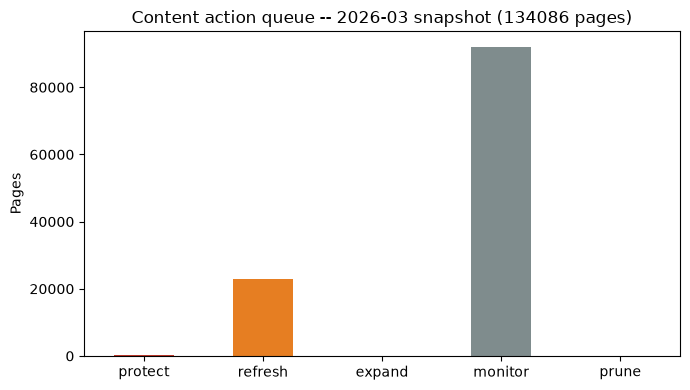

Saved chart to work/outputs/action_mix_chart.png


In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
action_counts.reindex(['protect', 'refresh', 'expand', 'monitor', 'prune']).fillna(0).plot(
    kind='bar', ax=ax, color=['#c0392b', '#e67e22', '#2980b9', '#7f8c8d', '#95a5a6']
)
ax.set_ylabel('Pages')
ax.set_title(f'Content action queue -- {MONTH} snapshot ({len(feature_frame)} pages)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/action_mix_chart.png', dpi=150)
plt.show()
print(f'Saved chart to {OUT_DIR}/action_mix_chart.png')

### 5.1 Model / analysis card

One page: what this is, what it's for, and where it breaks.

In [47]:
model_card = f"""# Content Action Playbook -- Model / Analysis Card

## What this is
A five-way triage queue (protect / refresh / expand / prune / monitor) for prioritizing content
review, built from FlyRank's {MONTH} warehouse snapshot. Two of the five buckets (protect, refresh)
are ranked using an out-of-fold Random Forest classifier ({y.mean():.1%} base rate,
grouped-split AUC 0.721, precision@50 0.96 on the `is_declining_proxy` label -- see w05/w06). The
other three buckets (expand, prune, monitor) are transparent rule-based heuristics with no
ground-truth validation available in this warehouse.

## What it's for
Helping a content team with limited review hours per cycle decide what to look at first. It is a
prioritization aid, not an auto-execution pipeline -- see Section 3's no-go list.

## Data
- `fact_content_daily_performance`, `dim_content`, `dim_clients` -- FlyRank internship warehouse,
  build v20260703.
- Feature window: {MONTH} only. Comparison window ({PREV_MONTH}) used solely to build the
  `is_declining_proxy` label, never as a feature (verified in w05 Section 3.1 / w06 Section 3).

## Method
- Baseline: transparent AND-gate rule (eligible x stale x CTR-gap), see w04/w05 Section 0.2.
- Model: Random Forest (n_estimators=300, max_depth=8, min_samples_leaf=20, class_weight=balanced),
  5-fold GroupKFold by client_hash_id, out-of-fold predictions only.
- Action assignment: priority-ordered rule set (Section 1.0-1.1) combining `pred_rf` with position,
  visibility, staleness, word count, and age -- full thresholds documented in Section 1.0's code cell.

## Performance (protect/refresh, validated against is_declining_proxy)
See Section 1.2's table for the current run's exact numbers; w05/w06 reported AUC 0.721-0.723 and
precision@50 of 0.96 on this same model spec.

## Changes this cycle (w07)
- Fixed `precision_at_k` to stop padding degenerate/near-all-zero scores out to K with arbitrary ties (affected the baseline column only; see the Changelog at the top of the notebook).
- Fixed the ranked queue to sort by action tier (protect > refresh > expand > monitor > prune) before priority_score, so a heuristic bucket can no longer outrank a validated protect/refresh row on traffic size alone.

## Where it breaks
- expand/prune/monitor are unvalidated heuristics (Section 2).
- Single-month snapshot; no rolling or out-of-time test yet (Section 4).
- `avg_position_mar` inherits a known no-data-day averaging bias (Section 0.3).
- Weaker for clients the model has not seen before (Section 2, citing w06's audit of the source paper).
- Label measures search-visibility decline only, not revenue or conversions.

## Owner / retrain cadence
Monthly, alongside the warehouse's monthly partitions (Section 4).
"""

with open(f'{OUT_DIR}/model_analysis_card.md', 'w') as f:
    f.write(model_card)

print(model_card)

# Content Action Playbook -- Model / Analysis Card

## What this is
A five-way triage queue (protect / refresh / expand / prune / monitor) for prioritizing content
review, built from FlyRank's 2026-03 warehouse snapshot. Two of the five buckets (protect, refresh)
are ranked using an out-of-fold Random Forest classifier (20.1% base rate,
grouped-split AUC 0.721, precision@50 0.96 on the `is_declining_proxy` label -- see w05/w06). The
other three buckets (expand, prune, monitor) are transparent rule-based heuristics with no
ground-truth validation available in this warehouse.

## What it's for
Helping a content team with limited review hours per cycle decide what to look at first. It is a
prioritization aid, not an auto-execution pipeline -- see Section 3's no-go list.

## Data
- `fact_content_daily_performance`, `dim_content`, `dim_clients` -- FlyRank internship warehouse,
  build v20260703.
- Feature window: 2026-03 only. Comparison window (2026-02) used solely to build the
  `is_decli

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.